<a href="https://colab.research.google.com/github/LuceroLE/Clinica-DentalMor/blob/cambios-Belen/CLINICA_DENTALMOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **----CLINICA DENTALMOR----**



---





*PASOS*


1.   Instalación de librerías.
2.   Conectar SQL con COLAB a través de NGROK: CLINICA_DENTAL
3.   Análisis exploratorio: head() y describe() (media, mediana, desviación típica y varianza).
4.   Distribución normal.
5.   Matriz de correlación. Variables: precio_tratamiento, ubicación de la clínica, antigüedad,
6.   Funnel: tasa de conversión de cliente esporádico a recurrente.

**1. Instalación de librerías**

In [ ]:
# Librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import gaussian_kde


**2. Conectar SQL con COLAB a través de NGROK: CLINICA_DENTAL**

In [ ]:
# 1º. Instalamos ngrok
!pip install pyngrok --force-reinstall

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 16.5 MB/s eta 0:00:00
  Attempting uninstall: PyYAML
    Found existing installation: PyYAML 6.0.3
    Uninstalling PyYAML-6.0.3:
      Successfully uninstalled PyYAML-6.0.3


In [ ]:
# 2º Importamos ngrok
from pyngrok import ngrok

# Your ngrok authentication token (from cell oqxEnzjFcEn_)
NGROK_AUTH_TOKEN = '3BoRq2aytOwy022xgdKHqCmG1TV_5uE7LDxMPxvBMbjUjeaBA'
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Open a tunnel to the PostgreSQL port (default is 5432)
# If your PostgreSQL is running on a different port, change 5432 accordingly
tunnel = ngrok.connect(5433, 'tcp')
print(f'Ngrok Tunnel URL: {tunnel.public_url}')

# Extract host and port for database connection
# The public_url will be in the format 'tcp://<host>:<port>'
ngrok_host = tunnel.public_url.split('//')[1].split(':')[0]
ngrok_port = tunnel.public_url.split('//')[1].split(':')[1]

print(f'Update your `host` variable to: "{ngrok_host}"')
print(f'Update your `port` variable to: "{ngrok_port}"')

# You can then use these variables in your database engine setup (cell GDFmFe3mcD1b)
# host = ngrok_host
# port = ngrok_port

Ngrok Tunnel URL: tcp://2.tcp.ngrok.io:25518
Update your `host` variable to: "2.tcp.ngrok.io"
Update your `port` variable to: "25518"


In [ ]:
# 3º Añadimos las librerías que nos hacen falta
from sqlalchemy import create_engine, text
import getpass # password de la base de datos
pd.set_option('display.max_columns', None)
sns.set_theme(style= 'whitegrid') # el estilo de la base de datos.

In [ ]:
# 4º Contraseña
host = '0.tcp.ngrok.io' # Replace with your ngrok host
port = '14174' # Replace with your ngrok port
database = 'CLINICA_DENTAL'
user = 'postgres'
password = getpass.getpass('Contraseña de PostgreSQL: ')

engine = create_engine(
    f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}'
)

Contraseña de PostgreSQL: ··········


In [ ]:
# 5º Arrancar el motor "con"
with engine.connect() as conn:
    resultado = pd.read_sql(text('SELECT 1 AS prueba_conexion'), conn)

resultado

OperationalError: (psycopg2.OperationalError) connection to server at "0.tcp.ngrok.io" (3.146.103.81), port 14174 failed: Connection refused
	Is the server running on that host and accepting TCP/IP connections?
connection to server at "0.tcp.ngrok.io" (18.190.63.84), port 14174 failed: Connection refused
	Is the server running on that host and accepting TCP/IP connections?
connection to server at "0.tcp.ngrok.io" (3.135.250.11), port 14174 failed: Connection refused
	Is the server running on that host and accepting TCP/IP connections?
connection to server at "0.tcp.ngrok.io" (3.12.57.198), port 14174 failed: Connection refused
	Is the server running on that host and accepting TCP/IP connections?
connection to server at "0.tcp.ngrok.io" (3.137.60.53), port 14174 failed: Connection refused
	Is the server running on that host and accepting TCP/IP connections?
connection to server at "0.tcp.ngrok.io" (3.12.245.36), port 14174 failed: Connection refused
	Is the server running on that host a

 **3. Análisis exploratorio**

In [ ]:
import numpy as np
import pandas as pd

# --- Generar datos de ventas con una distribución normal ---

# Establecer una semilla para reproducibilidad
np.random.seed(42)

# Generar un dataset aleatorio con las siguientes variables: precio_tratamiento, cantidad_profesionales, tiempo_cita, ubicación y antigüedad.
dataset={
    'precio_tratamiento': np.random.normal(loc=100, scale=20, size=10000),
    'cantidad_profesionales': np.random.normal(loc=2, scale=2, size=10000),
    'tiempo_cita': np.random.normal(loc=30, scale=10, size=10000),
    'ubicacion': np.random.choice(['urbana', 'rural'], size=10000),
    'antiguedad': np.random.normal(loc=1, scale=2, size=10000)
}

df_monthly = pd.DataFrame(dataset)


# Parámetros de la distribución normal para las ventas
mean_sales = 1000  # Media de las ventas
std_dev_sales = 200 # Desviación estándar de las ventas
num_samples = 10000  # Número de muestras (ventas simuladas)

# Generar datos de ventas que sigan una distribución normal
sales_data = np.random.normal(loc=mean_sales, scale=std_dev_sales, size=num_samples)

# Asegurarse de que las ventas no sean negativas (aunque una distribución normal puede tener valores negativos, en ventas no tiene sentido)
sales_data[sales_data < 0] = 0

df_sales = pd.DataFrame({'Ventas': sales_data})

print("Primeras 5 filas de las ventas simuladas:")
display(df_sales.head())

print("\nEstadísticas descriptivas de las ventas simuladas:")
display(df_sales.describe())

Primeras 5 filas de las ventas simuladas:


,Ventas
0,910.129517
1,955.495379
2,914.840984
3,1290.090500
4,1084.728425



Estadísticas descriptivas de las ventas simuladas:


,Ventas
count,10000.000000
mean,1000.053677
std,199.118884
min,315.724076
25%,866.857561
50%,1001.014853
75%,1133.765192
max,1749.075846


**4. Distribución normal**

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import gaussian_kde

# --- Visualizar la distribución de ventas con un histograma interactivo y KDE ---

fig = px.histogram(df_sales, x='Ventas',
                   nbins=30,
                   title='Distribución Normal de Ventas',
                   labels={'Ventas': 'Valor de Ventas', 'count': 'Frecuencia'},
                   color_discrete_sequence=['skyblue'],
                   marginal='rug') # Añade un 'rug plot' para ver los puntos individuales

# Añadir líneas para la media y la mediana
fig.add_vline(x=df_sales['Ventas'].mean(), line_dash="dash", line_color="red", annotation_text=f"Media: {df_sales['Ventas'].mean():.2f}", annotation_position="top right")
fig.add_vline(x=df_sales['Ventas'].median(), line_dash="dash", line_color="green", annotation_text=f"Mediana: {df_sales['Ventas'].median():.2f}", annotation_position="top left")

# Calcular y añadir la Estimación de Densidad de Kernel (KDE) para una curva suavizada
kde = gaussian_kde(df_sales['Ventas'])
x_kde = np.linspace(df_sales['Ventas'].min(), df_sales['Ventas'].max(), 500)
y_kde = kde(x_kde)
fig.add_trace(go.Scatter(x=x_kde, y=y_kde * (df_sales.shape[0] * (df_sales['Ventas'].max() - df_sales['Ventas'].min()) / 30), mode='lines', name='KDE', line=dict(color='orange', width=2)))

fig.update_layout(bargap=0.1) # Añadir un pequeño espacio entre las barras
fig.show()

# **TENDENCIAS**

*¿QUÉ OBSERVAR?*

-Variables más influyentes

-Posible multicolinealidad


# VARIABLES:
 (A) precio del tratamiento,(B) cantidad de profesionales, (C) ubicación, (D) tiempo de espera y (E) antigüedad.

*   **Precio del Tratamiento:** Costo de los diferentes servicios (limpiezas, empastes, blanqueamientos, ortodoncia, etc.).

*   **Cantidad de Profesionales:** Número de dentistas, higienistas, asistentes, recepcionistas.

*   **Ubicación:** Accesibilidad (transporte público, parking), visibilidad, demografía del área.

*   **Antigüedad de la Clínica:** Años de operación, establecimiento de la marca y reputación.

*   **Tiempo de Cita/Espera:** Duración promedio de las citas y tiempos de espera para conseguir una.

In [ ]:
#  MODELO CON SKLEARN
Preparar variables
X = df[['antigüedad', 'profesionales', 'tiempo_espera', 'ubicación']]
y = df['precio']


SyntaxError: invalid syntax (2375897233.py, line 2)

In [ ]:
# Train/test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Entrenar
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# Coeficientes
print(model.intercept_)
print(model.coef_)


NameError: name 'X' is not defined

In [ ]:
# EVALUACIÓN

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

pred = model.predict(X_test)

print("R2:", r2_score(y_test, pred))
print("MSE:", mean_squared_error(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))


NameError: name 'model' is not defined

**R²** → qué tanto explica el modelo

**MAE** → error promedio

**MSE** → penaliza errores grandes


**FUNNEL: EMBUDO DE CONVERSIÓN**

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# --- 1. Generar un dataset aleatorio con las variables especificadas ---
np.random.seed(42) # para reproducibilidad

num_leads = 5000 # Número inicial de leads/interesados

data_funnel = {
    'id_cliente': range(num_leads),
    'precio_tratamiento': np.random.normal(loc=100, scale=50, size=num_leads), # Precio promedio del tratamiento principal
    'tiempo_cita_min': np.random.normal(loc=30, scale=15, size=num_leads), # Duración promedio de la cita
    'antiguedad_clinica_anos': np.random.randint(1, 2, size=num_leads), # Años de operación de la clínica
    'ubicacion_clinica': np.random.choice(['Centro Urbano', 'Zona Residencial', 'Periferia'], size=num_leads, p=[0.5, 0.3, 0.2]),
    'cantidad_profesionales': np.random.randint(2, 5, size=num_leads) # Número de profesionales en la clínica
}

df_funnel = pd.DataFrame(data_funnel)

# Asegurar que algunos valores sean lógicos (e.g., no precios negativos o tiempos de cita muy bajos)
df_funnel['precio_tratamiento'] = df_funnel['precio_tratamiento'].apply(lambda x: max(50, x))
df_funnel['tiempo_cita_min'] = df_funnel['tiempo_cita_min'].apply(lambda x: max(15, x))

print("Primeras filas del dataset generado para el análisis de funnel:")
display(df_funnel.head())
print("\nEstadísticas descriptivas del dataset:")
display(df_funnel.describe())

# --- 2. Simular un Funnel de Conversión de una Clínica Dental ---

# Definir las etapas del funnel y sus tasas de conversión BASE
# Estas tasas pueden ser influenciadas por las variables del dataset
etapas_funnel = [
    "Visitas a Web/Clínica",
    "Contactos/Consultas Iniciales",
    "Citas Agendadas",
    "Citas Atendidas",
    "Planes de Tratamiento Aceptados",
    "Tratamientos Completados",
    "Clientes Recurrentes"
]

# Vamos a simular las conversiones de forma secuencial
# Influencias simplificadas de las variables en las tasas de conversión:
# - Ubicación: Mejor ubicación -> mayor conversión inicial
# - Precio: Precio más bajo -> mayor aceptación de tratamiento
# - Tiempo de cita: Menor tiempo de espera -> mayor agendamiento
# - Antigüedad: Mayor antigüedad -> más confianza, mayor recurrencia
# - Profesionales: Más profesionales -> mayor capacidad para agendar

# Valores iniciales para el funnel
visitas_web = num_leads

# Simulación de las conversiones
conversiones = {etapas_funnel[0]: visitas_web}

# Contactos/Consultas Iniciales (Influenciado por ubicación)
# Asumimos que la ubicación afecta la propensión a contactar
# Centro Urbano tiene una tasa de conversión más alta, Periferia más baja
conversion_contactos_base = 0.50
# Calcular una tasa de conversión ajustada por ubicación para cada lead individual
def get_contact_conversion(row):
    if row['ubicacion_clinica'] == 'Centro Urbano':
        return conversion_contactos_base * 1.1
    elif row['ubicacion_clinica'] == 'Zona Residencial':
        return conversion_contactos_base * 1.0
    else: # Periferia
        return conversion_contactos_base * 0.8

df_funnel['prob_contacto'] = df_funnel.apply(get_contact_conversion, axis=1)
num_contactos = visitas_web * df_funnel['prob_contacto'].mean()
conversiones[etapas_funnel[1]] = int(num_contactos)

# Citas Agendadas (Influenciado por tiempo_cita_min y cantidad_profesionales)
# Asumimos que tiempos de cita más cortos y más profesionales aumentan la conversión
conversion_agendadas_base = 0.65
# Ajuste basado en la media de tiempo_cita_min (cuanto más bajo, mejor)
avg_tiempo_cita = df_funnel['tiempo_cita_min'].mean()
conversion_agendadas_tiempo = conversion_agendadas_base * (1 + (45 - avg_tiempo_cita) / 100) # Ajuste simple: 45 min es el ideal
# Ajuste basado en la media de cantidad_profesionales (cuanto más alto, mejor)
avg_profesionales = df_funnel['cantidad_profesionales'].mean()
conversion_agendadas_prof = conversion_agendadas_tiempo * (1 + (avg_profesionales - 5) / 50) # Ajuste simple: 5 profesionales es el ideal

num_agendadas = conversiones[etapas_funnel[1]] * conversion_agendadas_prof
conversiones[etapas_funnel[2]] = int(num_agendadas)


# Citas Atendidas (Alta tasa de conversión, algunos no-shows)
conversion_atendidas = 0.85 # Tasa fija para simplicidad
num_atendidas = conversiones[etapas_funnel[2]] * conversion_atendidas
conversiones[etapas_funnel[3]] = int(num_atendidas)

# Planes de Tratamiento Aceptados (Influenciado por precio_tratamiento y antiguedad_clinica)
# Precios más bajos y mayor antigüedad pueden aumentar la aceptación
conversion_aceptados_base = 0.70
avg_precio_tratamiento = df_funnel['precio_tratamiento'].mean()
conversion_aceptados_precio = conversion_aceptados_base * (1 + (150 - avg_precio_tratamiento) / 300) # Ajuste simple: 150 es el precio ideal
avg_antiguedad = df_funnel['antiguedad_clinica_anos'].mean()
conversion_aceptados_antiguedad = conversion_aceptados_precio * (1 + (avg_antiguedad - 10) / 100) # Ajuste simple: 10 años es la antigüedad ideal

num_aceptados = conversiones[etapas_funnel[3]] * conversion_aceptados_antiguedad
conversiones[etapas_funnel[4]] = int(num_aceptados)

# Tratamientos Completados (Muy alta tasa de conversión, pocos abandonan)
conversion_completados = 0.95
num_completados = conversiones[etapas_funnel[4]] * conversion_completados
conversiones[etapas_funnel[5]] = int(num_completados)

# Clientes Recurrentes (Influenciado por antigüedad de la clínica y satisfacción, asumimos una tasa)
# Mayor antigüedad puede implicar más confianza y recurrencia
conversion_recurrentes_base = 0.60
conversion_recurrentes_antiguedad = conversion_recurrentes_base * (1 + (avg_antiguedad - 10) / 100) # Ajuste simple

num_recurrentes = conversiones[etapas_funnel[5]] * conversion_recurrentes_antiguedad
conversiones[etapas_funnel[6]] = int(num_recurrentes)

# Convertir el diccionario a listas para Plotly Funnel
etapas = list(conversiones.keys())
valores = list(conversiones.values())

print("\n--- Resultados del Funnel de Conversión Simulada ---")
for etapa, valor in zip(etapas, valores):
    print(f"{etapa}: {valor}")

# --- 3. Visualizar el Funnel ---

fig = go.Figure(go.Funnel(
    y = etapas,
    x = valores,
    textinfo = "value+percent initial"
))

fig.update_layout(title="Análisis Funnel de Clientes en Clínica Dental (Simulado)",
                  title_x=0.5, # Centrar el título
                  height=600,
                  margin=dict(l=150, r=150, t=80, b=80)) # Ajustar márgenes para mejor visualización

fig.show()

# --- 4. Interpretación básica ---
print("\n--- Interpretación ---")
print("Este funnel simula el recorrido de clientes en una clínica dental, desde el interés inicial hasta la recurrencia.")
print("Cada etapa muestra el número de clientes que avanzan, y el porcentaje respecto a la etapa inicial.")
print("Podemos observar dónde se producen las mayores 'caídas' (bajas tasas de conversión) para identificar posibles áreas de mejora.")
print(f"Por ejemplo, la conversión de 'Visitas a Web/Clínica' a 'Contactos/Consultas Iniciales' es del {valores[1]/valores[0]:.2%} en promedio, influenciada por la ubicación.")
print(f"La conversión de 'Citas Agendadas' a 'Citas Atendidas' es del {valores[3]/valores[2]:.2%}, indicando un buen cumplimiento de citas pero con algunos posibles 'no-shows'.")
print(f"La etapa de 'Planes de Tratamiento Aceptados' a 'Tratamientos Completados' tiene una alta conversión del {valores[5]/valores[4]:.2%}, lo cual es positivo.")
print(f"Finalmente, un {valores[6]/valores[5]:.2%} de los clientes que completan un tratamiento se convierten en 'Clientes Recurrentes', lo que es crucial para la sostenibilidad.")
print("Las tasas de conversión han sido ajustadas de forma simplificada por las variables del dataset (ubicación, precio, tiempo de cita, antigüedad, profesionales) para demostrar su posible impacto.")

Primeras filas del dataset generado para el análisis de funnel:


,id_cliente,precio_tratamiento,tiempo_cita_min,antiguedad_clinica_anos,ubicacion_clinica,cantidad_profesionales
0,0,124.835708,23.643605,1,Centro Urbano,2
1,1,93.086785,23.198788,1,Centro Urbano,2
2,2,132.384427,15.000000,1,Centro Urbano,2
3,3,176.151493,25.048647,1,Centro Urbano,3
4,4,88.292331,40.992436,1,Zona Residencial,2



Estadísticas descriptivas del dataset:


,id_cliente,precio_tratamiento,tiempo_cita_min,antiguedad_clinica_anos,cantidad_profesionales
count,5000.000000,5000.000000,5000.000000,5000.0,5000.000000
mean,2499.500000,104.383662,31.150494,1.0,3.004000
std,1443.520003,43.185063,13.101157,0.0,0.822265
min,0.000000,50.000000,15.000000,1.0,2.000000
25%,1249.750000,67.104748,19.701256,1.0,2.000000
50%,2499.500000,100.673280,29.738242,1.0,3.000000
75%,3749.250000,133.300530,40.158571,1.0,4.000000
max,4999.000000,296.311885,82.935828,1.0,4.000000



--- Resultados del Funnel de Conversión Simulada ---
Visitas a Web/Clínica: 5000
Contactos/Consultas Iniciales: 2522
Citas Agendadas: 1791
Citas Atendidas: 1522
Planes de Tratamiento Aceptados: 1116
Tratamientos Completados: 1060
Clientes Recurrentes: 578



--- Interpretación ---
Este funnel simula el recorrido de clientes en una clínica dental, desde el interés inicial hasta la recurrencia.
Cada etapa muestra el número de clientes que avanzan, y el porcentaje respecto a la etapa inicial.
Podemos observar dónde se producen las mayores 'caídas' (bajas tasas de conversión) para identificar posibles áreas de mejora.
Por ejemplo, la conversión de 'Visitas a Web/Clínica' a 'Contactos/Consultas Iniciales' es del 50.44% en promedio, influenciada por la ubicación.
La conversión de 'Citas Agendadas' a 'Citas Atendidas' es del 84.98%, indicando un buen cumplimiento de citas pero con algunos posibles 'no-shows'.
La etapa de 'Planes de Tratamiento Aceptados' a 'Tratamientos Completados' tiene una alta conversión del 94.98%, lo cual es positivo.
Finalmente, un 54.53% de los clientes que completan un tratamiento se convierten en 'Clientes Recurrentes', lo que es crucial para la sostenibilidad.
Las tasas de conversión han sido ajustadas de forma simpli

In [ ]:
# Análisis de sensibilidad tiempo_cita a la conversión.
import pandas as pd
import numpy as np
import plotly.express as px

# --- Análisis de Sensibilidad: Cómo afecta 'tiempo_cita' a la conversión de Citas Agendadas ---

# Definir el rango de 'tiempo_cita_min' a probar
tiempo_cita_range = np.arange(15, 76, 5) # De 15 a 75 minutos, en pasos de 5

sensitivity_results = []

# Extraer valores base del funnel del código anterior (CT6pDpin4gML)
conversion_agendadas_base = 0.65
avg_profesionales = df_funnel['cantidad_profesionales'].mean()
num_contactos = conversiones['Contactos/Consultas Iniciales'] # Usar el valor calculado del funnel

for test_tiempo_cita in tiempo_cita_range:
    # Recalcular la tasa de conversión para 'Citas Agendadas' con el nuevo 'tiempo_cita'
    # Ajuste basado en la media de tiempo_cita_min (cuanto más bajo, mejor)
    conversion_agendadas_tiempo = conversion_agendadas_base * (1 + (45 - test_tiempo_cita) / 100) # Ajuste simple

    # Aplicar el ajuste de profesionales (mantenemos constante para este análisis de sensibilidad)
    conversion_agendadas_prof = conversion_agendadas_tiempo * (1 + (avg_profesionales - 5) / 50) # Ajuste simple

    num_agendadas_simulated = num_contactos * conversion_agendadas_prof

    sensitivity_results.append({
        'Tiempo de Cita (min)': test_tiempo_cita,
        'Citas Agendadas': int(num_agendadas_simulated),
        'Tasa de Conversión (%)': round(conversion_agendadas_prof * 100, 2)
    })

df_sensitivity = pd.DataFrame(sensitivity_results)

print("\n--- Resultados del Análisis de Sensibilidad (Tiempo de Cita vs. Citas Agendadas) ---")
display(df_sensitivity)

# --- Visualizar la sensibilidad ---

fig_sensitivity = px.line(df_sensitivity,
                          x='Tiempo de Cita (min)',
                          y='Citas Agendadas',
                          title='Sensibilidad de Citas Agendadas a Tiempo de Cita',
                          labels={'Tiempo de Cita (min)': 'Duración Promedio de Cita (min)',
                                  'Citas Agendadas': 'Número de Citas Agendadas'},
                          markers=True)

fig_sensitivity.update_layout(xaxis_title_font_size=14,
                              yaxis_title_font_size=14,
                              title_font_size=18,
                              hovermode='x unified') # Muestra información unificada al pasar el ratón

fig_sensitivity.show()

print("\n--- Interpretación del Análisis de Sensibilidad ---")
print("El gráfico muestra cómo el número de 'Citas Agendadas' cambia al variar el 'Tiempo de Cita (min)'.")
print("Se observa que tiempos de cita más cortos tienden a resultar en un mayor número de citas agendadas, mientras que tiempos de cita más largos reducen esta conversión.")
print("Esto sugiere que la optimización del tiempo de espera y la duración de las citas es crucial para maximizar la cantidad de citas que los pacientes están dispuestos a agendar.")
print("La relación mostrada es lineal debido a la simplificación de los ajustes de conversión en el modelo de simulación.")


--- Resultados del Análisis de Sensibilidad (Tiempo de Cita vs. Citas Agendadas) ---


,Tiempo de Cita (min),Citas Agendadas,Tasa de Conversión (%)
0,15,2046,81.13
1,20,1967,78.01
2,25,1888,74.89
3,30,1809,71.77
4,35,1731,68.65
5,40,1652,65.53
6,45,1573,62.41
7,50,1495,59.28
8,55,1416,56.16
9,60,1337,53.04



--- Interpretación del Análisis de Sensibilidad ---
El gráfico muestra cómo el número de 'Citas Agendadas' cambia al variar el 'Tiempo de Cita (min)'.
Se observa que tiempos de cita más cortos tienden a resultar en un mayor número de citas agendadas, mientras que tiempos de cita más largos reducen esta conversión.
Esto sugiere que la optimización del tiempo de espera y la duración de las citas es crucial para maximizar la cantidad de citas que los pacientes están dispuestos a agendar.
La relación mostrada es lineal debido a la simplificación de los ajustes de conversión en el modelo de simulación.


### Análisis Comparativo de No-Shows por Segmento de Precio de Tratamiento

Para responder a la pregunta de cómo el precio del tratamiento influye en los no-shows, realizaremos la siguiente simulación:

1.  Partiremos del dataset `df_funnel` que contiene información sobre el precio de los tratamientos.
2.  Asignaremos una probabilidad de no-show a cada "cita agendada" simulada, donde esta probabilidad estará inversamente relacionada con el `precio_tratamiento` (a mayor precio, se asume mayor compromiso y menor probabilidad de no-show).
3.  Dividiremos los tratamientos en segmentos de precio (Bajo, Medio, Alto).
4.  Calcularemos la tasa de no-shows para cada segmento de precio.
5.  Visualizaremos estos resultados en un gráfico de barras comparativo.

In [ ]:
# Asegurarnos de que df_funnel está disponible (del cell CT6pDpin4gML)
# Creamos un DataFrame para este análisis específico basado en el df_funnel
df_no_shows_analysis = df_funnel[['id_cliente', 'precio_tratamiento', 'tiempo_cita_min', 'cantidad_profesionales']].copy()

# --- Simulación de la probabilidad de no-show basada en el precio del tratamiento ---

# Definir una tasa base de no-show (ej. 20%)
base_no_show_rate = 0.20

# Normalizar el precio del tratamiento para aplicar un efecto
min_price = df_no_shows_analysis['precio_tratamiento'].min()
max_price = df_no_shows_analysis['precio_tratamiento'].max()
df_no_shows_analysis['normalized_price'] = (df_no_shows_analysis['precio_tratamiento'] - min_price) / (max_price - min_price)

# La probabilidad de no-show disminuirá a medida que el precio normalizado aumente
# El factor 0.5 ajusta la fuerza de esta influencia
df_no_shows_analysis['no_show_prob'] = base_no_show_rate * (1 - df_no_shows_analysis['normalized_price'] * 0.5)

# Asegurarse de que la probabilidad esté dentro de un rango razonable (ej. 5% a 35%)
df_no_shows_analysis['no_show_prob'] = df_no_shows_analysis['no_show_prob'].clip(lower=0.05, upper=0.35)

# Simular si cada cita (representada por cada fila en df_no_shows_analysis) es un no-show
df_no_shows_analysis['is_no_show'] = np.random.rand(len(df_no_shows_analysis)) < df_no_shows_analysis['no_show_prob']

# --- Segmentación de precios y cálculo de tasas de no-show ---

# Definir los rangos de precios para los segmentos
bins = [0, 80, 150, np.inf] # Ej: Bajo (<80€), Medio (80-150€), Alto (>150€)
labels = ['Bajo (<80€)', 'Medio (80-150€)', 'Alto (>150€)']
df_no_shows_analysis['precio_segmento'] = pd.cut(df_no_shows_analysis['precio_tratamiento'], bins=bins, labels=labels, right=False)

# Calcular la tasa promedio de no-shows para cada segmento
no_show_rates_by_segment = df_no_shows_analysis.groupby('precio_segmento')['is_no_show'].mean().reset_index()
no_show_rates_by_segment['no_show_percentage'] = no_show_rates_by_segment['is_no_show'] * 100

print("\n--- Tasas de No-Show por Segmento de Precio de Tratamiento (Simulado) ---")
display(no_show_rates_by_segment)



--- Tasas de No-Show por Segmento de Precio de Tratamiento (Simulado) ---


/tmp/ipykernel_1584/2797677455.py:33: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,precio_segmento,is_no_show,no_show_percentage
0,Bajo (<80€),0.192757,19.275701
1,Medio (80-150€),0.164734,16.473411
2,Alto (>150€),0.144854,14.485388


In [ ]:
import plotly.express as px

# --- Visualización de las tasas de no-show por segmento de precio ---

fig = px.bar(no_show_rates_by_segment,
             x='precio_segmento',
             y='no_show_percentage',
             title='Tasa de No-Shows por Segmento de Precio de Tratamiento',
             labels={'precio_segmento': 'Segmento de Precio de Tratamiento',
                     'no_show_percentage': 'Porcentaje de No-Shows (%)'},
             color='no_show_percentage',
             color_continuous_scale=px.colors.sequential.Plasma_r) # Escala de color invertida

fig.update_layout(xaxis_title_font_size=14,
                  yaxis_title_font_size=14,
                  title_font_size=18)
fig.update_yaxes(range=[0, no_show_rates_by_segment['no_show_percentage'].max() * 1.1]) # Ajustar rango del eje Y
fig.show()


### Interpretación de los Resultados

El gráfico de barras muestra la tasa de no-shows (porcentaje de citas no atendidas) para diferentes segmentos de precio de tratamiento. Según nuestra simulación:

*   **Se observa una tendencia:** Los tratamientos con precios más bajos tienden a tener una tasa de no-shows más alta, mientras que los tratamientos con precios más altos presentan una tasa de no-shows más baja.
*   **Implicación:** Esto sugiere que los pacientes que han comprometido una mayor cantidad de dinero en un tratamiento tienen una mayor probabilidad de asistir a sus citas. Es un comportamiento esperado, ya que una inversión económica más significativa suele ir acompañada de un mayor compromiso.

Este análisis te permite:
*   **Identificar segmentos de riesgo:** Conocer qué rangos de precios están asociados a mayores tasas de no-shows.
*   **Estrategias de mitigación:** Considerar estrategias específicas para los segmentos de bajo precio, como recordatorios más frecuentes, sistemas de prepago parcial o penalizaciones por no-show, para fomentar la asistencia.

# **COMPORTAMIENTOS**

# **RELACIONES ENTRE VARIABLES**

In [12]:
# Machine Learning: Regresión lineal múltiple.
# ¿Qué variables que afectan a mi negocio (precio tratamiento, ubicación, antigüedad, cantidad de profesionales, tiempo_cita)?
# ¿Qué pasa si yo cambio una de ellas?

import numpy as np
import pandas as pd

np.random.seed(42)

n = 100

precio_tratamiento = np.random.randint(50, 150, n)
ubicacion = np.random.randint(1, 5, n)
antiguedad = np.random.randint(0, 5, n)
cantidad_profesionales = np.random.randint(0, 30, n)
tiempo_cita = np.random.randint(0, 15, n)

precio = 50 + 2*cantidad_profesionales - 1.5*antiguedad + np.random.randn(n)*10

df = pd.DataFrame({
    "precio": precio_tratamiento,
    "ubicacion": ubicacion,
    "antiguedad": antiguedad,
    "cantidad_profesionales": cantidad_profesionales,
    "tiempo_cita": tiempo_cita
})

df

,precio,ubicacion,antiguedad,cantidad_profesionales,tiempo_cita
0,101,2,4,4,12
1,142,1,0,26,0
2,64,4,4,22,13
3,121,4,3,8,4
4,110,4,3,8,14
...,...,...,...,...,...
95,134,3,0,2,11
96,129,2,1,27,11
97,131,4,0,8,4
98,102,2,3,4,6


<Axes: >

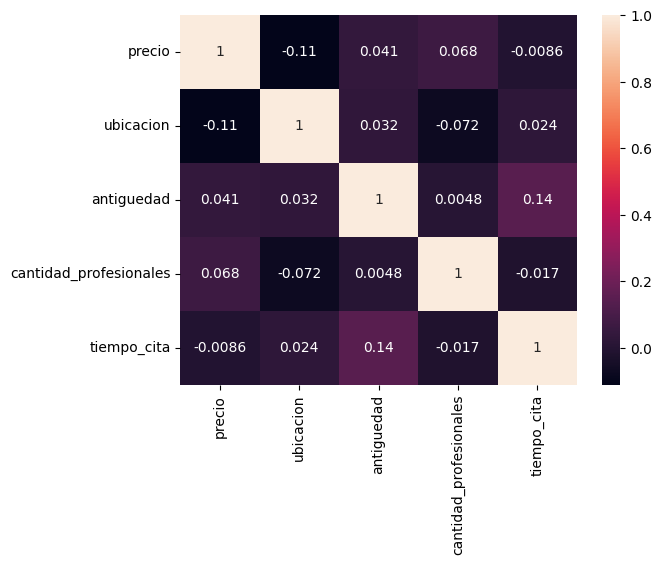

In [13]:
# Mapa correlación

import seaborn as sns

sns.heatmap(df.corr(), annot=True)



# **---**


In [ ]:
# 2.   Gráficos dinámicos para métricas
# PUNTOS

import plotly.express as px

# Ensure df_sales is available from previous cells
if 'df_sales' in locals() or 'df_sales' in globals():
    fig = px.scatter(x=range(len(df_sales['Ventas'])), y=df_sales['Ventas'],
                     title='Dispersión de Valores de Ventas (Dinámico)',
                     labels={'x': 'Índice de Venta', 'y': 'Valor de Venta'},
                     opacity=0.6)
    fig.update_layout(xaxis_title='Índice de Venta', yaxis_title='Valor de Venta')
    fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey')
    fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey')
    fig.show()
else:
    print("Error: df_sales DataFrame not found. Please run the sales data generation cells first.")

In [ ]:
# 2. Gráficos dinámicos para métricas
# BARRAS Y PROBABILIDAD (CAMPANA DE GAUSS)

import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
import numpy as np

# Ensure df_sales is available from previous cells
if 'df_sales' in locals() or 'df_sales' in globals():
    fig = px.histogram(x=df_sales['Ventas'], nbins=30, title='Distribución de Ventas (Dinámico)',
                       labels={'x': 'Valor de Ventas', 'count': 'Frecuencia'},
                       color_discrete_sequence=['skyblue'],
                       histnorm='probability density', # Normalize to show probability density
                       marginal='rug' # Add a rug plot for individual data points
                      )

    # Calculate KDE
    kde = gaussian_kde(df_sales['Ventas'])
    x_kde = np.linspace(df_sales['Ventas'].min(), df_sales['Ventas'].max(), 500)
    y_kde = kde(x_kde)

    # Add KDE trace as a scatter plot
    fig.add_trace(go.Scatter(x=x_kde, y=y_kde, mode='lines', name='KDE', line=dict(color='red', width=2)))

    fig.update_layout(bargap=0.1) # Add some gap between bars for better visualization
    fig.show()
else:
    print("Error: df_sales DataFrame not found. Please run the sales data generation cells first.")

# **PROBABILIDAD CONDICIONAL: PROMO HIGIENE DENTAL INICIAL Y 2º TRATAMIENTO**

In [ ]:
# PROBABILIDAD CONDICIONAL

import numpy as np

# 1. Preparar los datos: Agrupar por cuatrimestre
# Crear una columna de cuatrimestre
df_monthly['quarter'] = (df_monthly['month'] - 1) // 4 + 1

# Agrupar por año y cuatrimestre para obtener ventas y órdenes cuatrimestrales
df_quarterly = df_monthly.groupby(['year', 'quarter']).agg(
    total_net_sales=('net_sales', 'sum'),
    total_orders=('orders', 'sum')
).reset_index()

print("Datos de ventas cuatrimestrales:\n")
print(df_quarterly.head())
print("\n")

# 2. Definir Eventos A y B
# Usaremos la mediana como umbral para definir 'alto' en ventas netas y órdenes
threshold_sales = df_quarterly['total_net_sales'].median()
threshold_orders = df_quarterly['total_orders'].median()

print(f"Umbral de Ventas Netas (mediana): {threshold_sales:.2f}")
print(f"Umbral de Órdenes (mediana): {threshold_orders:.2f}\n")

# Evento A: Higiene dental
# Evento B: Tratamiento2

# 3. Calcular ocurrencias
total_quarters = len(df_quarterly)

occurrences_A = df_quarterly[df_quarterly['total_net_sales'] > threshold_sales].shape[0]
occurrences_B = df_quarterly[df_quarterly['total_orders'] > threshold_orders].shape[0]
occurrences_A_and_B = df_quarterly[
    (df_quarterly['total_net_sales'] > threshold_sales) &
    (df_quarterly['total_orders'] > threshold_orders)
].shape[0]

print(f"Total de trimestres: {total_quarters}")
print(f"Trimestres con Ventas Netas Altas (A): {occurrences_A}")
print(f"Trimestres con Órdenes Altas (B): {occurrences_B}")
print(f"Trimestres con Ventas Netas Altas Y Órdenes Altas (A y B): {occurrences_A_and_B}\n")

# 4. Calcular probabilidades
P_A = occurrences_A / total_quarters
P_B = occurrences_B / total_quarters
P_A_and_B = occurrences_A_and_B / total_quarters

print(f"P(A) = Probabilidad de Ventas Netas Altas: {P_A:.4f}")
print(f"P(B) = Probabilidad de Órdenes Altas: {P_B:.4f}")
print(f"P(A y B) = Probabilidad de Ventas Netas Altas Y Órdenes Altas: {P_A_and_B:.4f}\n")

# 5. Calcular la probabilidad condicional P(A|B) = P(A y B) / P(B)
if P_B > 0:
    P_A_given_B = P_A_and_B / P_B
    print(f"P(A|B) = Probabilidad de Ventas Netas Altas DADO Órdenes Altas: {P_A_given_B:.4f}")
    print("\nInterpretación: Este es el porcentaje de trimestres con órdenes altas que también tuvieron ventas netas altas.")
else:
    print("No hay trimestres con órdenes altas (B), por lo tanto, no se puede calcular P(A|B).")

NameError: name 'df_monthly' is not defined

In [ ]:
# EJEMPLO CREADO CON IA: PROBABILIDAD CONDICIONAL
import pandas as pd
import numpy as np

# Establecemos una semilla para la reproducibilidad de los datos simulados
np.random.seed(42)

# Número total de clientes simulados
num_customers = 1000

# 1. Simulación de datos de clientes
# Asumimos que un porcentaje de clientes se hizo la higiene de promoción
prob_promo_hygiene = 0.60 # 60% de los clientes se hacen la promoción
has_promo_hygiene = np.random.rand(num_customers) < prob_promo_hygiene

# Asumimos que un porcentaje de los clientes QUE SE HICIERON LA PROMOCIÓN
# regresan para otro tratamiento. Esta es la probabilidad que queremos estimar.
# Aquí lo simulamos directamente para el ejemplo.
prob_return_after_promo_simulated = 0.45 # 45% de los que tuvieron promo, regresan

returned_for_other_treatment = np.zeros(num_customers, dtype=bool)
# Para los clientes que tuvieron la higiene de promoción, simulamos si regresaron
returned_for_other_treatment[has_promo_hygiene] = np.random.rand(np.sum(has_promo_hygiene)) < prob_return_after_promo_simulated

# Creamos un DataFrame con los datos simulados
df_customers = pd.DataFrame({
    'customer_id': range(1, num_customers + 1),
    'had_promotional_hygiene': has_promo_hygiene,
    'returned_for_other_treatment': returned_for_other_treatment
})

print("Muestra de datos de clientes simulados:")
print(df_customers.head())
print("\n")

# 2. Definir Eventos
# Evento A: Cliente se hizo una higiene dental de promoción
# Evento B: Cliente volvió a la clínica a hacerse otro tratamiento (después de la promo)

# 3. Calcular ocurrencias
total_customers = len(df_customers)

# Clientes que tuvieron la higiene de promoción (Evento A)
customers_event_A = df_customers['had_promotional_hygiene'].sum()

# Clientes que tuvieron la higiene de promoción Y volvieron para otro tratamiento (Evento A y B)
customers_event_A_and_B = df_customers[df_customers['had_promotional_hygiene'] & df_customers['returned_for_other_treatment']].shape[0]

print(f"Total de clientes simulados: {total_customers}")
print(f"Clientes que se hicieron la higiene de promoción (Evento A): {customers_event_A}")
print(f"Clientes que se hicieron la higiene de promoción Y volvieron para otro tratamiento (Evento A y B): {customers_event_A_and_B}\n")

# 4. Calcular probabilidades
# P(A) = Probabilidad de que un cliente se haga la higiene de promoción
P_A = customers_event_A / total_customers

# P(A y B) = Probabilidad de que un cliente se haga la higiene de promoción Y vuelva para otro tratamiento
P_A_and_B = customers_event_A_and_B / total_customers

print(f"P(A) = Probabilidad de que un cliente se haga la higiene de promoción: {P_A:.4f}")
print(f"P(A y B) = Probabilidad de que un cliente se haga la higiene de promoción Y vuelva para otro tratamiento: {P_A_and_B:.4f}\n")

# 5. Calcular la probabilidad condicional P(B|A) = P(A y B) / P(A)
# Esta es la probabilidad de que un cliente vuelva (B) DADO que se hizo la higiene de promoción (A)
if P_A > 0:
    P_B_given_A = P_A_and_B / P_A
    print(f"P(Volver | Higiene Promoción) = Probabilidad de que un cliente vuelva para otro tratamiento DADO que se hizo la higiene de promoción: {P_B_given_A:.4f}")
    print("\nInterpretación: Este valor representa la probabilidad estimada de que un cliente, una vez que ha aprovechado la promoción de higiene dental, regrese a la clínica para realizarse algún otro tratamiento. Cuanto mayor sea este número, más efectiva es la promoción para fidelizar clientes.")
else:
    print("No hay clientes que se hayan hecho la higiene de promoción, por lo tanto, no se puede calcular la probabilidad condicional.")


Muestra de datos de clientes simulados:
   customer_id  had_promotional_hygiene  returned_for_other_treatment
0            1                     True                          True
1            2                    False                         False
2            3                    False                         False
3            4                     True                         False
4            5                     True                         False


Total de clientes simulados: 1000
Clientes que se hicieron la higiene de promoción (Evento A): 613
Clientes que se hicieron la higiene de promoción Y volvieron para otro tratamiento (Evento A y B): 262

P(A) = Probabilidad de que un cliente se haga la higiene de promoción: 0.6130
P(A y B) = Probabilidad de que un cliente se haga la higiene de promoción Y vuelva para otro tratamiento: 0.2620

P(Volver | Higiene Promoción) = Probabilidad de que un cliente vuelva para otro tratamiento DADO que se hizo la higiene de promoción: 0.4274

I

In [ ]:
#Gráfico

import plotly.express as px

# Preparar los datos para la visualización
plot_data = df_customers.groupby(['had_promotional_hygiene', 'returned_for_other_treatment']).size().reset_index(name='count')

# Renombrar las columnas para etiquetas más claras en el gráfico
plot_data['had_promotional_hygiene'] = plot_data['had_promotional_hygiene'].map({True: 'Con Promoción de Higiene', False: 'Sin Promoción de Higiene'})
plot_data['returned_for_other_treatment'] = plot_data['returned_for_other_treatment'].map({True: 'Volvió para Otro Tratamiento', False: 'No Volvió para Otro Tratamiento'})

# Crear el gráfico de barras agrupadas
fig = px.bar(plot_data,
             x='had_promotional_hygiene',
             y='count',
             color='returned_for_other_treatment',
             barmode='group',
             title='Relación entre Promoción de Higiene y Regreso para Otro Tratamiento',
             labels={'had_promotional_hygiene': 'Se Hizo Higiene Promocional',
                     'count': 'Número de Clientes',
                     'returned_for_other_treatment': 'Estado de Regreso'},
             color_discrete_map={'Volvió para Otro Tratamiento': 'skyblue',
                                 'No Volvió para Otro Tratamiento': 'lightcoral'})

fig.update_layout(xaxis_title_font_size=14,
                  yaxis_title_font_size=14,
                  legend_title_text='Estado del Cliente',
                  title_font_size=18)

fig.show()

In [ ]:
# Gráfico circular de retorno de clientes (solo para quienes tomaron la promoción)

import plotly.express as px

# Filtrar solo los clientes que tuvieron la higiene promocional
promo_customers = df_customers[df_customers['had_promotional_hygiene'] == True]

# Contar cuántos regresaron y cuántos no
return_counts = promo_customers['returned_for_other_treatment'].value_counts().reset_index()
return_counts.columns = ['Returned', 'Count']

# Mapear los valores booleanos a etiquetas claras
return_counts['Returned'] = return_counts['Returned'].map({True: 'Volvieron para Otro Tratamiento', False: 'No Volvieron para Otro Tratamiento'})

# Crear el gráfico circular
fig = px.pie(return_counts,
             values='Count',
             names='Returned',
             title='Proporción de Clientes que Regresaron (Tras Promoción de Higiene)',
             color='Returned',
             color_discrete_map={'Volvieron para Otro Tratamiento': 'skyblue',
                                 'No Volvieron para Otro Tratamiento': 'lightcoral'})

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(showlegend=True)
fig.show()

### Cálculo del Impacto Económico de Clientes Recurrentes

Para calcular el impacto económico, necesitamos definir algunos supuestos sobre el valor económico de un cliente que regresa y el costo de la promoción.

In [ ]:
# 1. Definir valores económicos (pueden ser estimados o reales de tu clínica)

# Ingreso promedio que genera un cliente al regresar para otro tratamiento
# Por ejemplo, si el tratamiento promedio posterior a la higiene es un empaste, blanqueamiento, etc.
average_revenue_per_returning_treatment = 150  # Ejemplo: 150 euros/dólares por tratamiento

# Costo de la higiene dental promocional (si la promoción es a costo o con poca ganancia, esto es importante)
# Es el costo para la clínica de realizar la higiene, no el precio de venta al cliente.
cost_of_promo_hygiene = 30  # Ejemplo: 30 euros/dólares por higiene

# Supongamos que la promoción de higiene tiene un precio de venta bajo (ej: 40) para atraer, generando un pequeño margen inicial
price_of_promo_hygiene = 40 # Ejemplo: 40 euros/dólares de precio de venta al cliente

# El beneficio directo de la higiene promocional (puede ser negativo si es una oferta 'a pérdida' para atraer)
profit_from_promo_hygiene = price_of_promo_hygiene - cost_of_promo_hygiene

print(f"Ingreso promedio esperado por cliente recurrente: {average_revenue_per_returning_treatment:.2f}")
print(f"Costo de la higiene promocional para la clínica: {cost_of_promo_hygiene:.2f}")
print(f"Beneficio directo por cada higiene promocional: {profit_from_promo_hygiene:.2f}")

Ingreso promedio esperado por cliente recurrente: 150.00
Costo de la higiene promocional para la clínica: 30.00
Beneficio directo por cada higiene promocional: 10.00


In [ ]:
# 2. Calcular el número de clientes que regresaron gracias a la promoción
# Este valor ya lo calculamos previamente: customers_event_A_and_B
num_returning_customers = customers_event_A_and_B

# 3. Calcular el ingreso adicional generado por los clientes recurrentes
total_additional_revenue = num_returning_customers * average_revenue_per_returning_treatment

# 4. Calcular el beneficio total considerando la promoción
# Beneficio de las higienes promocionales realizadas (para todos los que la hicieron)
# customers_event_A es el total de clientes que tomaron la promoción
total_profit_from_all_promo_hygienes = customers_event_A * profit_from_promo_hygiene

# Impacto económico total = (Beneficio de higienes promocionales) + (Ingresos adicionales de recurrentes)
total_economic_impact = total_profit_from_all_promo_hygienes + total_additional_revenue

print(f"\nNúmero de clientes que regresaron para otro tratamiento: {num_returning_customers}")
print(f"Ingreso adicional total generado por clientes recurrentes: {total_additional_revenue:.2f}")
print(f"Beneficio directo total de todas las higienes promocionales: {total_profit_from_all_promo_hygienes:.2f}")
print(f"\nIMPACTO ECONÓMICO TOTAL DE LA PROMOCIÓN: {total_economic_impact:.2f}")

print("\nInterpretación: Este es el valor monetario estimado que tu clínica ha generado (o podría generar) gracias a la promoción de higiene, considerando tanto el beneficio directo de las higienes como el valor a largo plazo de los clientes que regresaron.")


Número de clientes que regresaron para otro tratamiento: 262
Ingreso adicional total generado por clientes recurrentes: 39300.00
Beneficio directo total de todas las higienes promocionales: 6130.00

IMPACTO ECONÓMICO TOTAL DE LA PROMOCIÓN: 45430.00

Interpretación: Este es el valor monetario estimado que tu clínica ha generado (o podría generar) gracias a la promoción de higiene, considerando tanto el beneficio directo de las higienes como el valor a largo plazo de los clientes que regresaron.


In [ ]:
# Analizar qué otros tratamientos comunes regresan los clientes

import numpy as np
import pandas as pd

# --- Simulación de datos extendida para incluir tipos de tratamiento ---

np.random.seed(42) # Aseguramos la reproducibilidad
num_customers = 1000

# Simulación de si tuvieron higiene promocional (como antes)
has_promo_hygiene = np.random.rand(num_customers) < 0.60 # 60% hicieron la promo

# Simulación de si regresaron para otro tratamiento (como antes)
returned_for_other_treatment = np.zeros(num_customers, dtype=bool)
prob_return_after_promo_simulated = 0.45
returned_for_other_treatment[has_promo_hygiene] = np.random.rand(np.sum(has_promo_hygiene)) < prob_return_after_promo_simulated

# Lista de tratamientos comunes que podrían elegir los clientes recurrentes
common_treatments = ['Empaste', 'Blanqueamiento', 'Ortodoncia', 'Endodoncia', 'Limpieza Profesional']

# Asignar un tratamiento a los clientes que regresaron
# Para aquellos que regresaron, asignamos aleatoriamente un tratamiento de la lista
treatment_type = np.full(num_customers, 'No Regresó', dtype=object) # Valor por defecto
returning_indices = np.where(returned_for_other_treatment)[0]

if len(returning_indices) > 0:
    # Asignamos tratamientos aleatorios a los clientes que regresaron
    treatment_type[returning_indices] = np.random.choice(common_treatments, size=len(returning_indices))

# Creamos el DataFrame actualizado
df_customers_extended = pd.DataFrame({
    'customer_id': range(1, num_customers + 1),
    'had_promotional_hygiene': has_promo_hygiene,
    'returned_for_other_treatment': returned_for_other_treatment,
    'treatment_type': treatment_type
})

print("Muestra de datos de clientes extendidos:\n")
print(df_customers_extended.head())
print("\n")

# --- Análisis de tratamientos comunes para clientes recurrentes ---

# Filtrar solo a los clientes que regresaron para otro tratamiento
returning_customers_data = df_customers_extended[df_customers_extended['returned_for_other_treatment'] == True]

if not returning_customers_data.empty:
    # Contar la frecuencia de cada tipo de tratamiento
    common_returning_treatments = returning_customers_data['treatment_type'].value_counts()

    print("Tratamientos más comunes entre los clientes recurrentes:\n")
    print(common_returning_treatments)

    # Visualización (opcional): Gráfico de barras de tratamientos comunes
    import plotly.express as px

    fig = px.bar(common_returning_treatments,
                 x=common_returning_treatments.index,
                 y=common_returning_treatments.values,
                 title='Frecuencia de Tratamientos Comunes entre Clientes Recurrentes',
                 labels={'x': 'Tipo de Tratamiento', 'y': 'Número de Clientes'},
                 color=common_returning_treatments.index,
                 color_discrete_sequence=px.colors.qualitative.Pastel)

    fig.update_layout(xaxis_tickangle=-45)
    fig.show()
else:
    print("No hay clientes recurrentes en los datos simulados para analizar los tratamientos.")

Muestra de datos de clientes extendidos:

   customer_id  had_promotional_hygiene  returned_for_other_treatment  \
0            1                     True                          True   
1            2                    False                         False   
2            3                    False                         False   
3            4                     True                         False   
4            5                     True                         False   

         treatment_type  
0  Limpieza Profesional  
1            No Regresó  
2            No Regresó  
3            No Regresó  
4            No Regresó  


Tratamientos más comunes entre los clientes recurrentes:

treatment_type
Limpieza Profesional    60
Endodoncia              59
Blanqueamiento          53
Empaste                 48
Ortodoncia              42
Name: count, dtype: int64


### Comparación de la Tasa de Retorno según el Tipo de Tratamiento

Vamos a calcular la probabilidad de que un cliente, habiendo tomado la promoción de higiene, regrese para *cada tipo específico* de tratamiento. Esto nos permitirá comparar la "tasa de retorno" efectiva para cada servicio, entendiendo esta tasa como la proporción de clientes promocionales que eligieron un tratamiento particular.

In [ ]:
# Calcular la tasa de retorno para cada tipo de tratamiento específico entre los
# clientes que tuvieron la higiene promocional

# Filtrar para clientes que tuvieron higiene promocional
promo_customers_extended = df_customers_extended[df_customers_extended['had_promotional_hygiene'] == True]

# Obtener el número total de clientes que tuvieron higiene promocional
total_promo_customers = promo_customers_extended.shape[0]

# Inicializar un diccionario para almacenar las tasas de retorno para cada tipo de tratamiento
treatment_return_rates = {}

# Iterar a través de cada tratamiento común
for treatment in common_treatments:
    # Contar clientes que tuvieron higiene promocional Y regresaron para este tratamiento específico
    count_promo_and_specific_treatment = promo_customers_extended[
        (promo_customers_extended['returned_for_other_treatment'] == True) &
        (promo_customers_extended['treatment_type'] == treatment)
    ].shape[0]

    # Calcular la probabilidad condicional P(Regresó para tratamiento_específico | Tuvo higiene promocional)
    if total_promo_customers > 0:
        rate = count_promo_and_specific_treatment / total_promo_customers
        treatment_return_rates[treatment] = rate
    else:
        treatment_return_rates[treatment] = 0

# Convertir el diccionario a un DataFrame para una visualización más sencilla
df_treatment_return_rates = pd.DataFrame(treatment_return_rates.items(), columns=['Tipo de Tratamiento', 'Tasa de Retorno'])
df_treatment_return_rates = df_treatment_return_rates.sort_values(by='Tasa de Retorno', ascending=False)


print("Tasa de retorno por tipo de tratamiento (para clientes que tuvieron higiene promocional):\n")
print(df_treatment_return_rates)

# Visualización
import plotly.express as px

fig = px.bar(df_treatment_return_rates,
             x='Tipo de Tratamiento',
             y='Tasa de Retorno',
             title='Tasa de Retorno por Tipo de Tratamiento (Clientes con Higiene Promocional)',
             labels={'Tipo de Tratamiento': 'Tipo de Tratamiento', 'Tasa de Retorno': 'Tasa de Retorno'},
             color='Tasa de Retorno',
             color_continuous_scale=px.colors.sequential.Viridis)

fig.update_layout(xaxis_tickangle=-45)
fig.show()


Tasa de retorno por tipo de tratamiento (para clientes que tuvieron higiene promocional):

    Tipo de Tratamiento  Tasa de Retorno
4  Limpieza Profesional         0.097879
3            Endodoncia         0.096248
1        Blanqueamiento         0.086460
0               Empaste         0.078303
2            Ortodoncia         0.068515


# ENTRENAMOS EL MODELO

In [ ]:
print("--- Modelo Original (TV, Radio) ---")
X_original = df_mkt[['tv', 'radio']]
y = df_mkt['sales']

model_original = LinearRegression()
model_original.fit(X_original, y)
y_pred_original = model_original.predict(X_original)

mae_original = mean_absolute_error(y, y_pred_original)
mse_original = mean_squared_error(y, y_pred_original)
rmse_original = np.sqrt(mse_original)
r2_original = r2_score(y, y_pred_original)

print(f"Coeficientes (TV, Radio): {model_original.coef_}, Intercepto: {model_original.intercept_:.2f}")
print(f"MAE: {mae_original:.2f}, MSE: {mse_original:.2f}, RMSE: {rmse_original:.2f}, R2: {r2_original:.2f}")

In [10]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import gaussian_kde

# Establecer una semilla para reproducibilidad
np.random.seed(43) # Usamos una semilla diferente para un nuevo conjunto de datos

# --- 1. Generar un conjunto de datos aleatorio con una distribución normal desplazada a la izquierda ---
# Para desplazar la campana a la izquierda, usaremos una media negativa o un valor bajo.
mean_shifted = -5  # Media negativa para un claro desplazamiento a la izquierda
std_dev = 3      # Desviación estándar
num_samples = 1000 # Número de muestras

shifted_data = np.random.normal(loc=mean_shifted, scale=std_dev, size=num_samples)

df_shifted = pd.DataFrame({'Valores': shifted_data})

print("Primeras 5 filas del dataset desplazado:")
display(df_shifted.head())
print("\nEstadísticas descriptivas del dataset desplazado:")
display(df_shifted.describe())

# --- 2. Visualizar la distribución con un histograma interactivo y KDE ---

fig = px.histogram(df_shifted, x='Valores',
                   nbins=30,
                   title='Distribución Normal Desplazada a la Izquierda',
                   labels={'Valores': 'Valor', 'count': 'Frecuencia'},
                   color_discrete_sequence=['lightgreen'],
                   histnorm='probability density', # Normalizar para densidad de probabilidad
                   marginal='rug') # Añadir un 'rug plot' para ver los puntos individuales

# Calcular y añadir la Estimación de Densidad de Kernel (KDE) para una curva suavizada
kde = gaussian_kde(df_shifted['Valores'])
x_kde = np.linspace(df_shifted['Valores'].min(), df_shifted['Valores'].max(), 500)
y_kde = kde(x_kde)
fig.add_trace(go.Scatter(x=x_kde, y=y_kde, mode='lines', name='KDE', line=dict(color='darkgreen', width=2)))

# Añadir línea para la media
fig.add_vline(x=df_shifted['Valores'].mean(), line_dash="dash", line_color="red", annotation_text=f"Media: {df_shifted['Valores'].mean():.2f}", annotation_position="top right")

fig.update_layout(bargap=0.05) # Pequeño espacio entre barras
fig.show()

# --- 3. Interpretación ---
print("\n--- Interpretación de la Distribución Desplazada ---")
print("Este gráfico muestra un conjunto de datos que sigue una distribución normal, pero con su 'campana de Gauss' claramente desplazada hacia la izquierda del eje Y (hacia valores negativos).")
print(f"La media de esta distribución es de aproximadamente {df_shifted['Valores'].mean():.2f}, lo que confirma que el centro de la mayoría de los datos se encuentra en el lado izquierdo del espectro. Esto podría representar, por ejemplo, mediciones de un proceso donde los valores bajos son más comunes o un ajuste a un punto de referencia negativo. La simetría de la campana indica que la dispersión de los datos alrededor de esta media sigue un patrón normal, pero el posicionamiento general del conjunto de valores se inclina hacia la izquierda.")
print("En un contexto práctico, un desplazamiento a la izquierda podría indicar:")
print("  - **Rendimiento:** Un proceso que generalmente tiene puntuaciones bajas.")
print("  - **Tiempo de respuesta:** Un sistema que tiene tiempos de respuesta muy rápidos (bajos) la mayor parte del tiempo.")
print("  - **Mediciones:** Valores que están mayormente en el rango negativo o bajo de una escala.")

Primeras 5 filas del dataset desplazado:


,Valores
0,-4.227800
1,-7.725444
2,-6.135509
3,-6.604747
4,-2.425780



Estadísticas descriptivas del dataset desplazado:


,Valores
count,1000.000000
mean,-4.989549
std,2.967962
min,-14.077220
25%,-6.949384
50%,-4.989441
75%,-3.050598
max,3.728600



--- Interpretación de la Distribución Desplazada ---
Este gráfico muestra un conjunto de datos que sigue una distribución normal, pero con su 'campana de Gauss' claramente desplazada hacia la izquierda del eje Y (hacia valores negativos).
La media de esta distribución es de aproximadamente -4.99, lo que confirma que el centro de la mayoría de los datos se encuentra en el lado izquierdo del espectro. Esto podría representar, por ejemplo, mediciones de un proceso donde los valores bajos son más comunes o un ajuste a un punto de referencia negativo. La simetría de la campana indica que la dispersión de los datos alrededor de esta media sigue un patrón normal, pero el posicionamiento general del conjunto de valores se inclina hacia la izquierda.
En un contexto práctico, un desplazamiento a la izquierda podría indicar:
  - **Rendimiento:** Un proceso que generalmente tiene puntuaciones bajas.
  - **Tiempo de respuesta:** Un sistema que tiene tiempos de respuesta muy rápidos (bajos) la mayo